In [1]:
import osmnx as ox
import city2graph
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.lines import Line2D
from shapely.geometry import box

D:\GIS\Projects\venvs\copenhagen-walkability\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
city_name = "Copenhagen Municipality"
crs = 25832

admin = ox.geocode_to_gdf(city_name).to_crs(crs)
poi_gdf = ox.features_from_place(city_name, {"amenity": "cafe"}).to_crs(crs)

In [3]:
def plot_net_graph(boundaries_gdf, network_gdf, linewidth=0.4, alpha=0.7, color="#2b2b2b"):
    fig, ax = plt.subplots(figsize=(10, 10))

    boundaries_gdf.boundary.plot(ax=ax, linewidth=0.5, color="#2b2b2b")
    network_gdf.plot(ax=ax, linewidth=linewidth, color=color, alpha=alpha)

    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

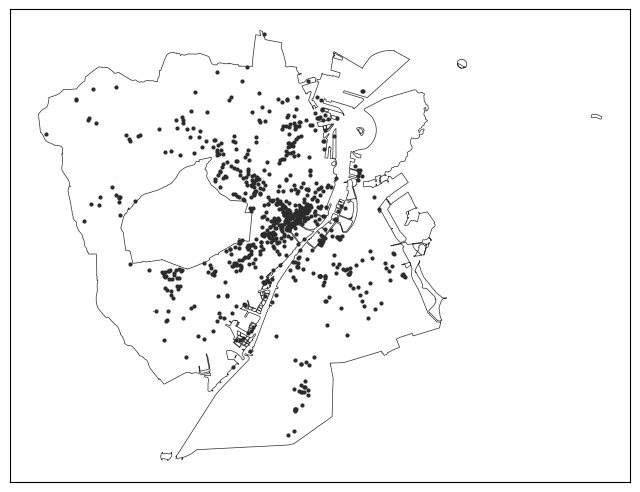

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))

admin.boundary.plot(ax=ax, linewidth=0.5, color="#2b2b2b")
poi_gdf.plot(ax=ax, markersize=4, color="#2b2b2b")

ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

In [5]:
network_drive = ox.graph_to_gdfs(ox.graph_from_place(city_name, network_type="drive"), nodes=False).to_crs(crs)
network_walk = ox.graph_to_gdfs(ox.graph_from_place(city_name, network_type="walk"), nodes=False).to_crs(crs)

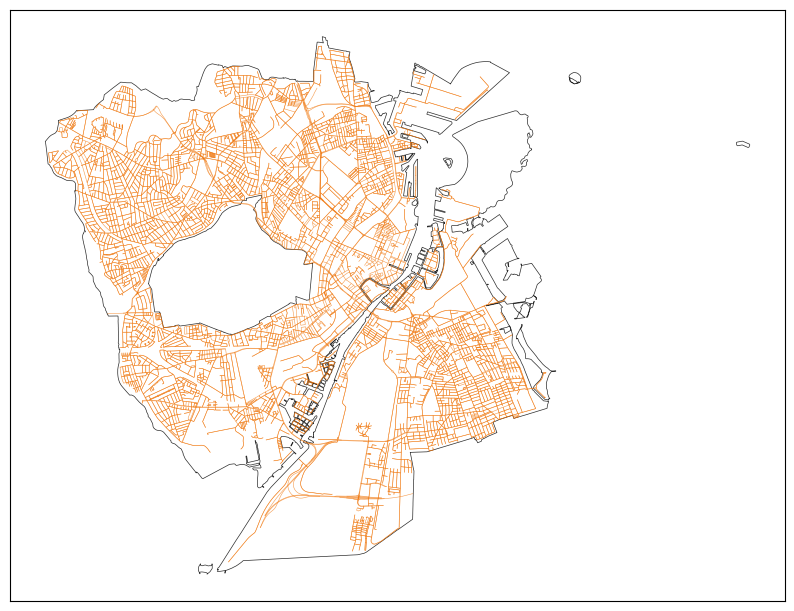

In [6]:
plot_net_graph(admin, network_drive, color="#f07102")

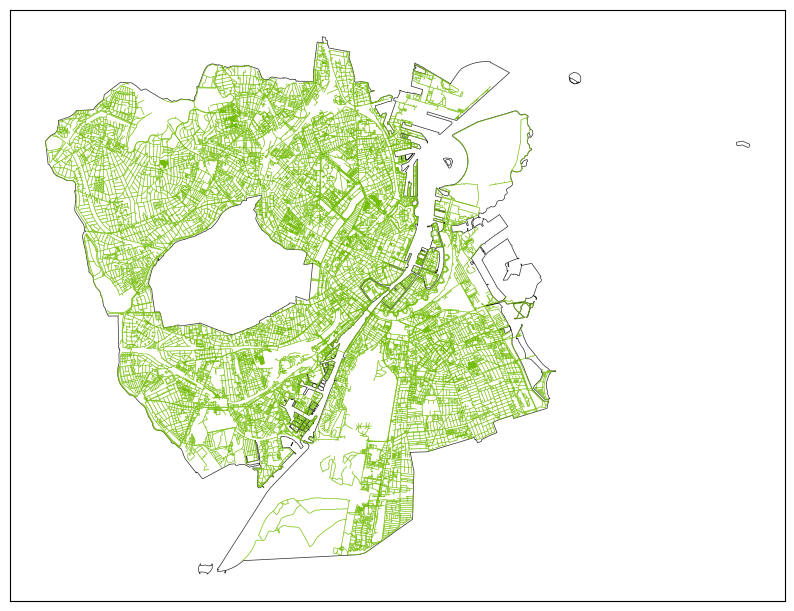

In [7]:
plot_net_graph(admin, network_walk, color="#72bd02")